In [52]:
import json
import pandas as pd
import numpy as np
from datetime import datetime
import prettytable as pt
from matplotlib import pyplot as plt
import os 
import warnings
warnings.filterwarnings("ignore")

###################################################################################################
                                                                                                  #
from rhoova.Client import *                                                                       #   
#Register and get api key from https://app.rhoova.com/ for ClientConfig("api key", "api secret")  #
config = ClientConfig("", "")                                                                     #
api = Api(config)                                                                                 # 
                                                                                                  #
###################################################################################################

directory = os.path.normpath(os.getcwd() + os.sep + os.pardir)
datadirectory=directory+"/data/yielddata/yielddata.csv"

yielddata = pd.read_csv(datadirectory)
yielddata = yielddata.replace(np.nan, '', regex=True) 


In [53]:
# Fix parameters for building yield curve instruments
instrumentsconfig={
            "DEPO": {
                "businessDayConvention": "ModifiedFollowing",
                "dayCounter": "Actual360"
            },
            "FUTURES": {
                "businessDayConvention": "ModifiedFollowing",
                "dayCounter": "Actual360",
                "market": "IMM",
                "usedates": True
            },
            "IRS": {
                "businessDayConvention": "ModifiedFollowing",
                "dayCounter": "Actual360",
                "frequency": "Semiannual"
            }
        } 

In [54]:
# Fix parameters for building yield curve

yieldcurveconfig={
        "settlementDays": 2,
        "intpMethod": "LINEAR",
        "currency": "USD",
        "calendar": "UnitedStates",
        "dayCounter": "Actual360",
        "period": "3M",
        "instruments":instrumentsconfig,}

In [55]:
yieldcurve =  {
    "valuationDate": "2021-06-02",
    "yieldCurve":yieldcurveconfig ,
    "yieldData": yielddata.to_dict('r')
}
try:
    result = api.createTask(CalculationType.YIELD_CURVE, yieldcurve,True)
    result=json.loads(result["result"])
except RhoovaError as e:
    e.printPretty()

In [56]:
zerorates=result.get("zeroRates"),
discountrates=result.get("discountRates")
dates=[]
forwarddates= {}
rhoovayieldcurvedicts = {}
rhoovayieldcurvediscounts = {}
for rhvzr in zerorates[0]:
    rhoovayieldcurvedicts[datetime.strptime(rhvzr.get('date'),'%Y-%m-%d').date()] = rhvzr.get('rate')*100
    dates.append(rhvzr.get('date'))

for rhv in discountrates:
    rhoovayieldcurvediscounts[datetime.strptime(rhv.get('date'), '%Y-%m-%d').date()] = rhv.get('rate')
    

In [57]:
bloombergzerorates=[0.13026,0.13026,0.12933,0.12543,0.1399,0.14339,0.15367,0.17113,0.2277,0.42095,0.66016,0.88188,
                    1.08274,1.25338,1.38811,1.49866,1.59246,1.67237,1.74239,1.88604,2.00444,2.04047,2.04536,
                    1.94349,1.81266]
bloombergdiscountrates=[1.00,0.999661,0.999635,0.999334,0.998908,0.998524,0.998006,0.997354,0.99545,0.98744,
                        0.973922,0.956841,0.937073,0.915908,0.894827,0.87375,0.852713,0.831854,0.811132,0.753435,
                        0.669541,0.600223,0.541152,0.459309,0.403764]

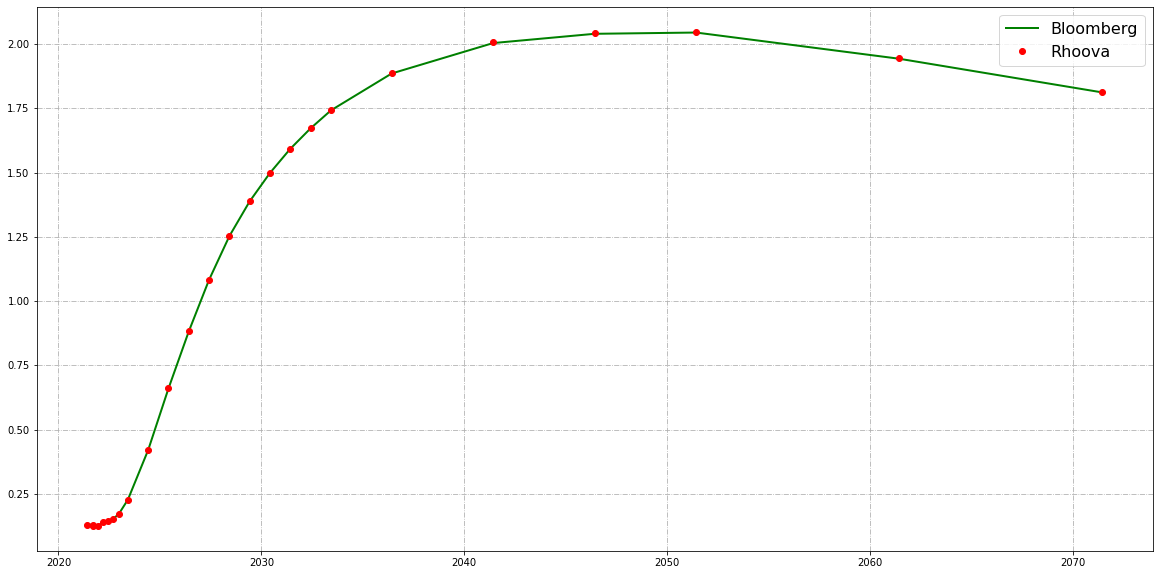

In [58]:
fig, ax = plt.subplots(figsize=(20, 10))

x=list(rhoovayieldcurvedicts.keys())
y1 =bloombergzerorates
y2 = list(rhoovayieldcurvedicts.values())


ax.plot(x,y1, 'g', label='Bloomberg', linewidth=2)
ax.plot(x,y2, 'ro', label='Rhoova', linewidth=4)
#
leg = ax.legend(prop={'size': 16});
plt.grid(linestyle='dashdot')
plt.show()

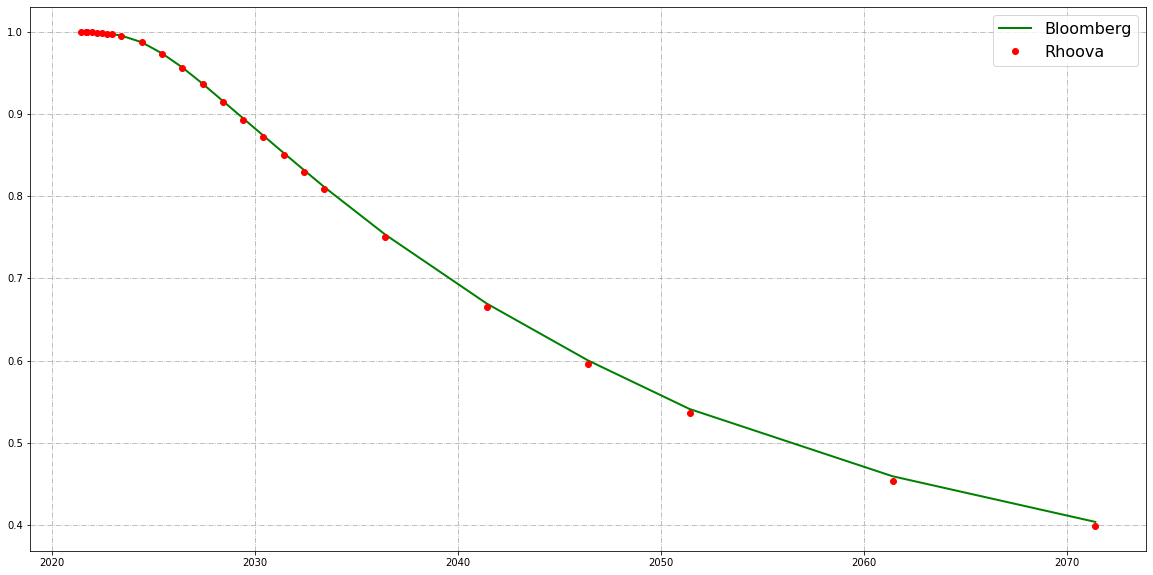

In [59]:
fig, ax = plt.subplots(figsize=(20, 10))

x=list(rhoovayieldcurvediscounts.keys())
y1 =bloombergdiscountrates
y2 = list(rhoovayieldcurvediscounts.values())

ax.plot(x,y1, 'g', label='Bloomberg', linewidth=2)
ax.plot(x,y2, 'ro', label='Rhoova', linewidth=12)

leg = ax.legend(prop={'size': 16});
plt.grid(linestyle='dashdot')
plt.show()

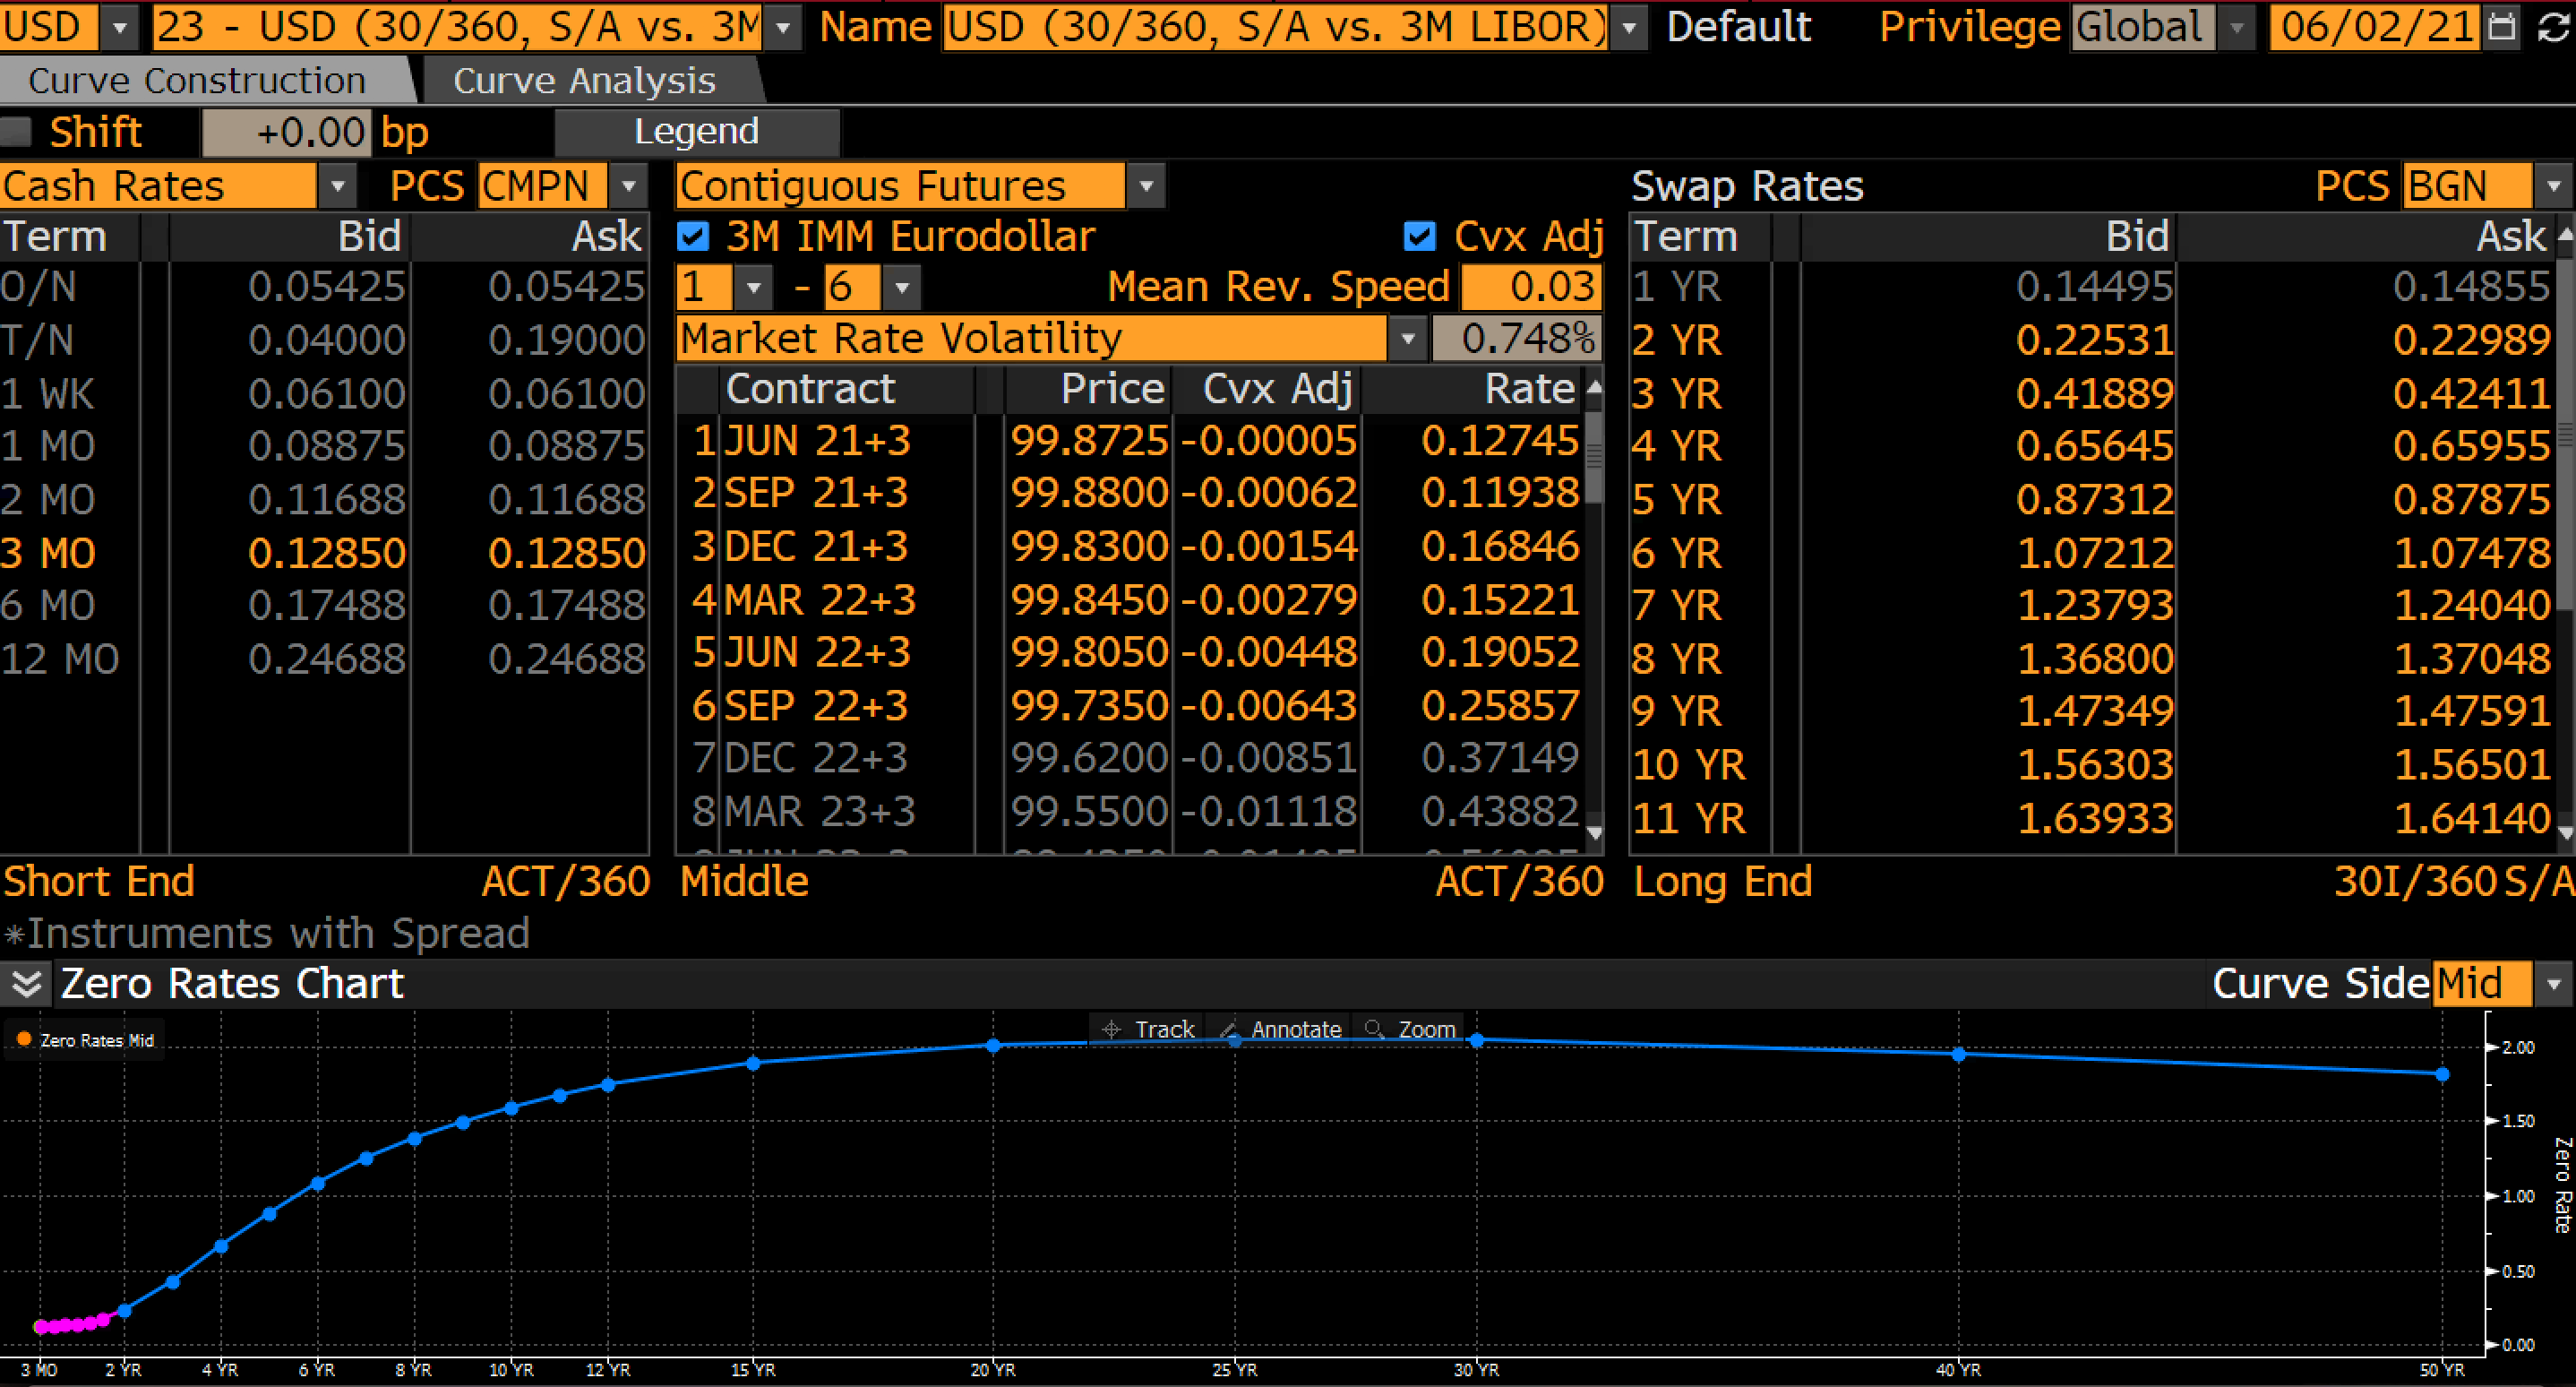

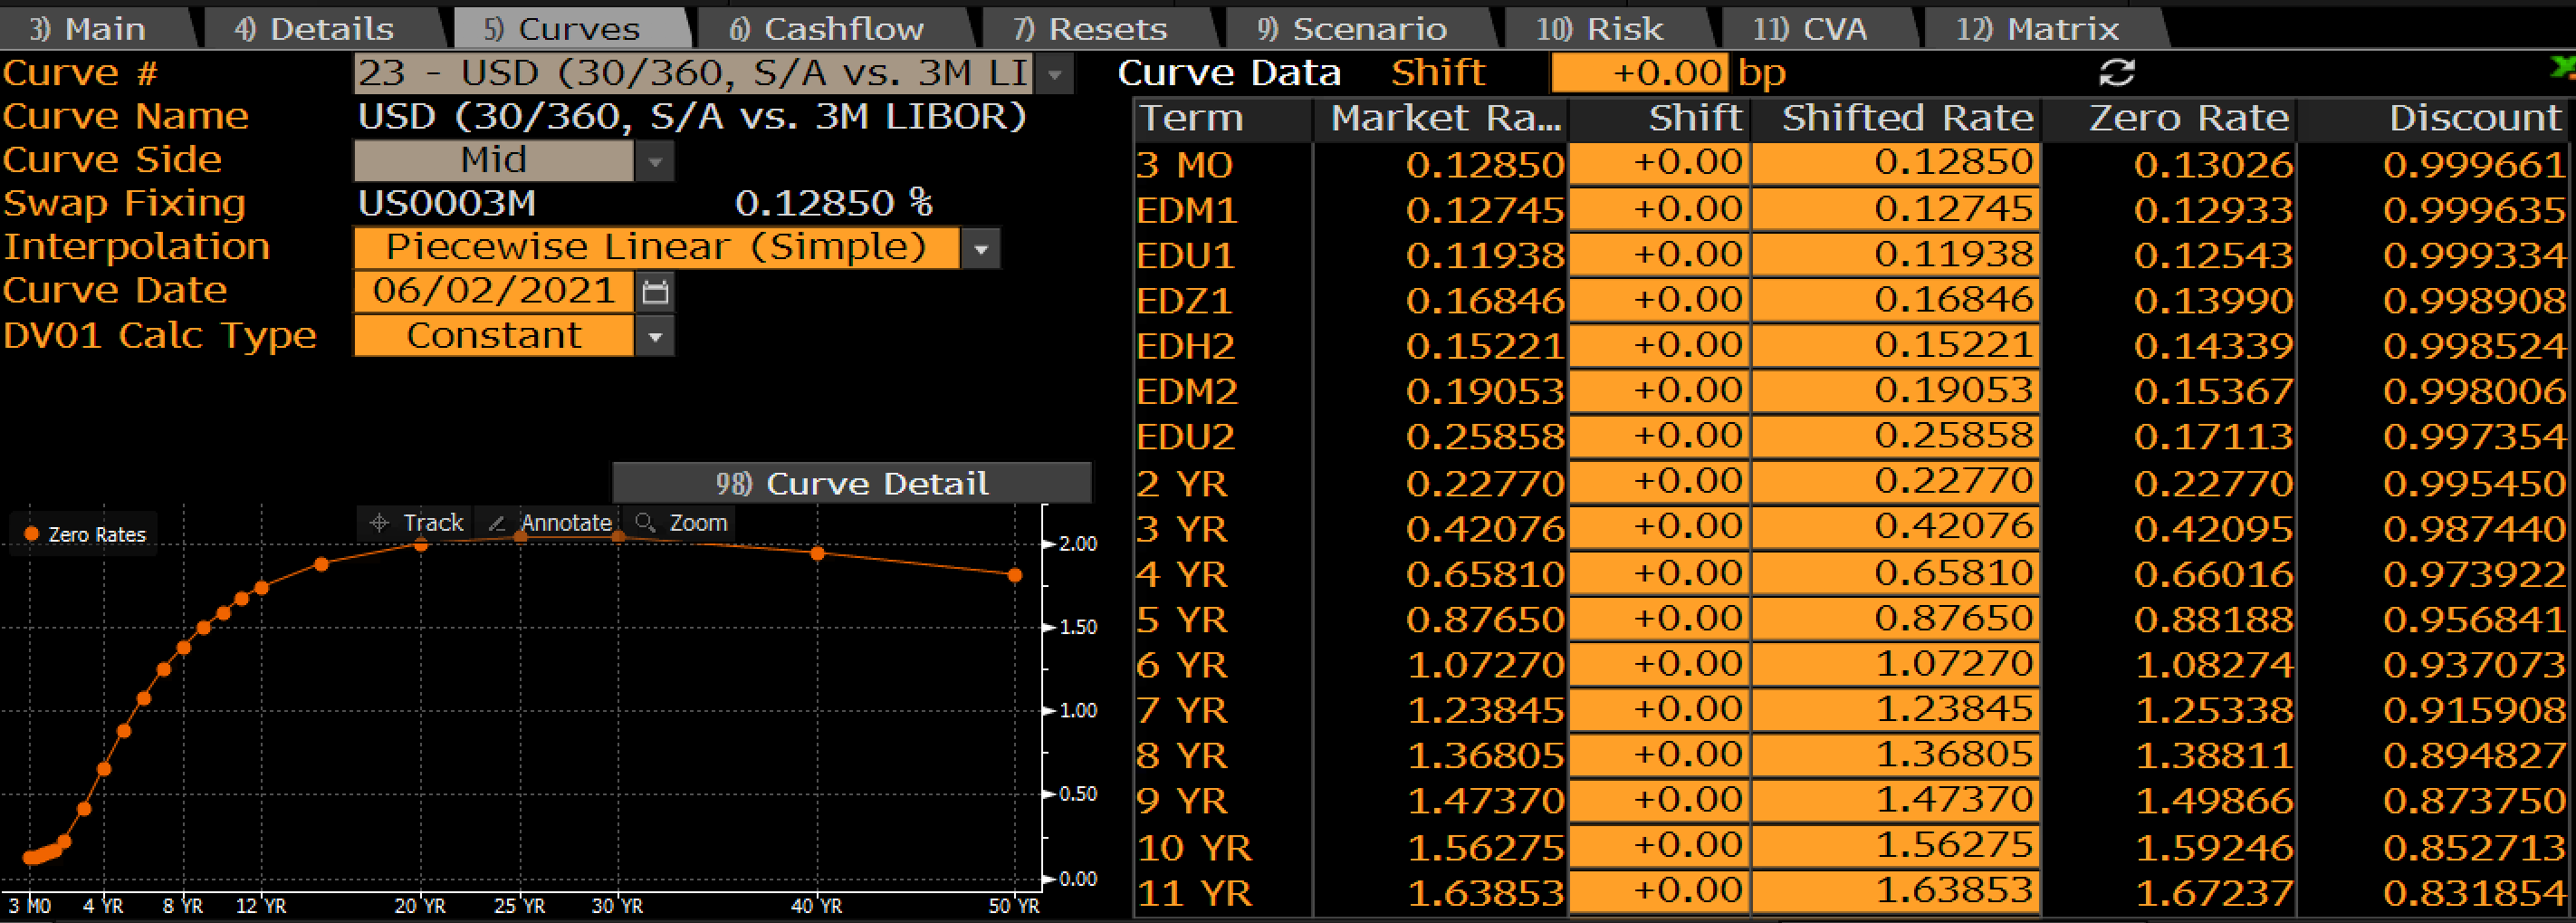

In [60]:
pTable = pt.PrettyTable(['Maturity','Rhoova ZeroRates','Bloomberg ZR','Rhoova Discount Rate','Bloomberg DR'])
i=0
for key, val in rhoovayieldcurvedicts.items():
    pTable.add_row([key, val,bloombergzerorates[i],rhoovayieldcurvediscounts.get(key),bloombergdiscountrates[i]])
    i=i+1
pTable.align = 'c'
pTable.float_format = '.6'
print(pTable)

+------------+------------------+--------------+----------------------+--------------+
|  Maturity  | Rhoova ZeroRates | Bloomberg ZR | Rhoova Discount Rate | Bloomberg DR |
+------------+------------------+--------------+----------------------+--------------+
| 2021-06-04 |     0.128478     |   0.130260   |          1           |   1.000000   |
| 2021-09-07 |     0.128478     |   0.130260   |       0.999661       |   0.999661   |
| 2021-09-16 |     0.126489     |   0.129330   |       0.999635       |   0.999635   |
| 2021-12-15 |     0.124726     |   0.125430   |       0.999328       |   0.999334   |
| 2022-03-15 |     0.139854     |   0.139900   |       0.998897       |   0.998908   |
| 2022-06-16 |     0.144188     |   0.143390   |       0.998491       |   0.998524   |
| 2022-09-15 |     0.153638     |   0.153670   |       0.998005       |   0.998006   |
| 2022-12-21 |     0.172117     |   0.171130   |       0.997302       |   0.997354   |
| 2023-06-05 |     0.227698     |   0.22770

In [61]:
# Define shock parameters

yieldcurveconfig['applyShock']={
  "method": "parallel",
  "shockValues" : [
    {
      "tenor" : "all",
      "shockValue" : 50.0
    }
  ]
}

In [62]:
result =  {
    "valuationDate": "2021-06-02",
    "endOfMonth": True,
    "yieldCurve":yieldcurveconfig ,
    "yieldData": yielddata.to_dict('r')
}
try:
    result = api.createTask(CalculationType.YIELD_CURVE, result,True)
    presult=json.loads(result["result"])
except RhoovaError as e:
    e.printPretty()

In [63]:
zerorates=presult.get("zeroRates"),
discountrates=presult.get("discountRates")
dates=[]
forwarddates= {}
rhoovapyieldcurvedicts = {}
rhoovapyieldcurvediscounts = {}
for rhvzr in zerorates[0]:
    rhoovapyieldcurvedicts[datetime.strptime(rhvzr.get('date'),'%Y-%m-%d').date()] = rhvzr.get('rate')*100
    dates.append(rhvzr.get('date'))

for rhv in discountrates:
    rhoovapyieldcurvediscounts[datetime.strptime(rhv.get('date'), '%Y-%m-%d').date()] = rhv.get('rate')
    

In [64]:
bloombergshiftedmarketrates=[0.6285,0.627450119,0.619375077,0.668457736,0.652206235,0.690519723,0.758569906,
                              0.727600001,0.921499997,1.158000499,1.375930011,1.573450506,1.739165008,1.869239986,
                              1.974700034,2.064020038,2.140365541,2.2051,2.33950001,2.451399982,2.49000001,
                              2.501249969,2.43870002]
bloombergshiftedzerorates=[0.636701315,0.636701315,0.635835695,0.631919286,0.646367734,0.649841327,0.66009861,
                            0.677536876,0.793197438,0.965224039,1.193656939,1.40953834,1.608779834,1.777420208,
                            1.911516816,2.021093805,2.114737904,2.194914755,2.263818366,2.40714556,2.524893812,
                            2.558327731,2.560127643,2.445148585,2.298140635]
bloombergshifteddiscountrates=[1.00,0.998344205,0.998207333,0.99664694,0.994965734,0.993328101,0.991464397,
                                0.989566907,0.984239832,0.971432818,0.953344472,0.931913263,0.907945553,0.882880427,
                                0.858107337,0.833593682,0.809296711,0.785353749,0.7618784,0.69674511,0.603309686,
                                0.527291117,0.463662011,0.375737951,0.31669191]

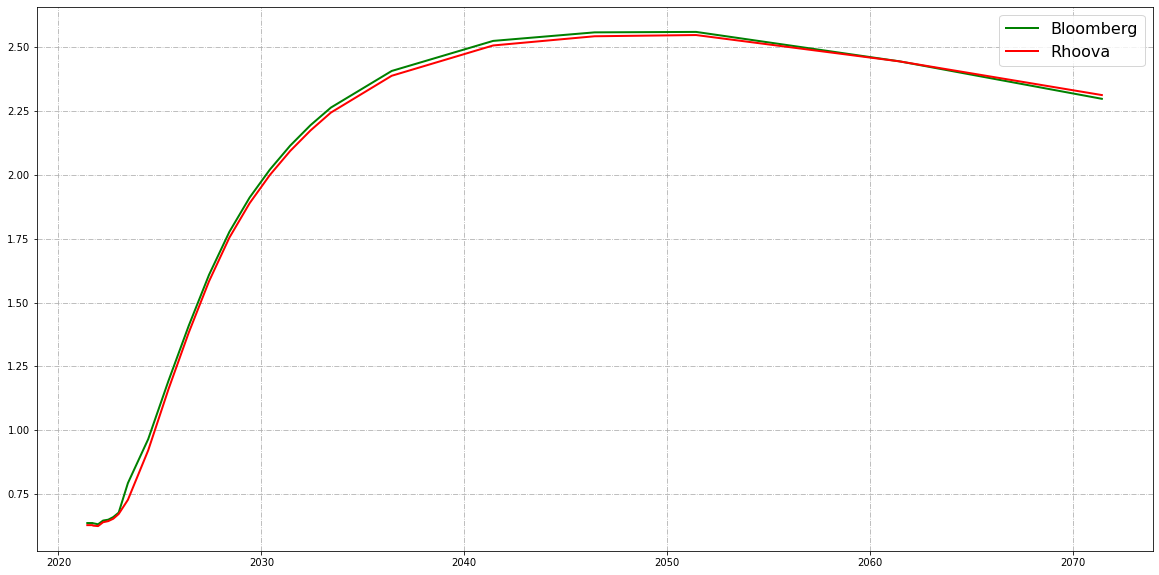

In [66]:
fig, ax = plt.subplots(figsize=(20, 10))

x=list(rhoovapyieldcurvedicts.keys())
y1 =bloombergshiftedzerorates
y2 = list(rhoovapyieldcurvedicts.values())


ax.plot(x,y1, 'g', label='Bloomberg', linewidth=2)
ax.plot(x,y2, 'r', label='Rhoova', linewidth=2)

leg = ax.legend(prop={'size': 16});
plt.grid(linestyle='dashdot')
plt.show()

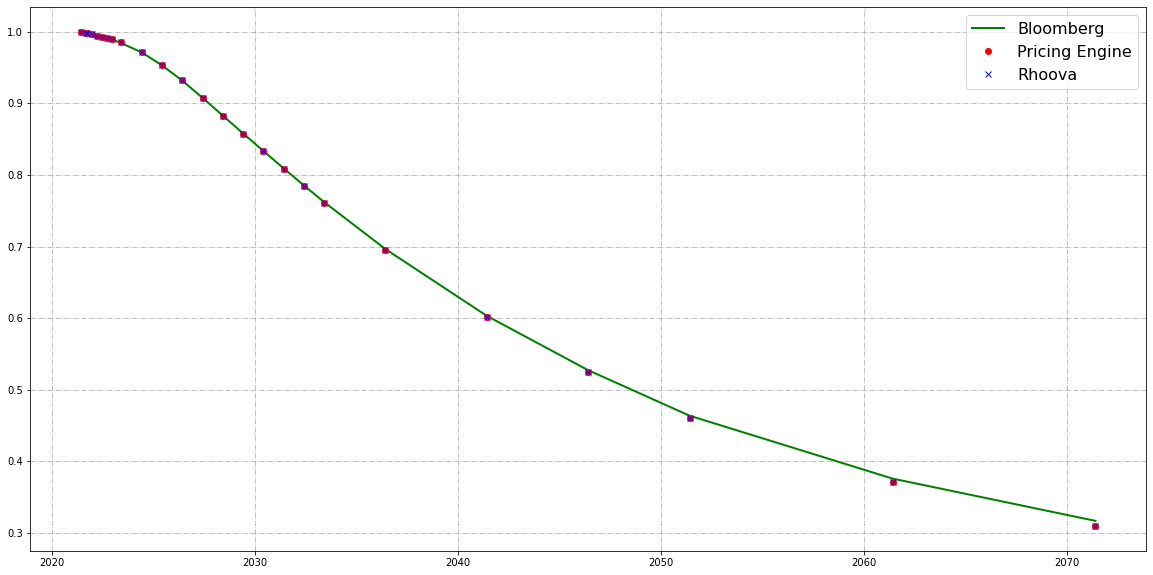

In [75]:
fig, ax = plt.subplots(figsize=(20, 10))

x=list(rhoovapyieldcurvediscounts.keys())
y1 =bloombergshifteddiscountrates
y2 = list(rhoovapyieldcurvediscounts.values())
y3 = list(rhoovapyieldcurvediscounts.values())


ax.plot(x,y1, 'g', label='Bloomberg', linewidth=2)
ax.plot(x,y2, 'ro', label='Pricing Engine', linewidth=8)
ax.plot(x,y3, 'bx', label='Rhoova', linewidth=4)


leg = ax.legend(prop={'size': 16});
plt.grid(linestyle='dashdot')
plt.show()

In [76]:
pTable = pt.PrettyTable(['Maturity','Rhoova ZeroRates','Bloomberg ZR','Rhoova Discount Rate','Bloomberg DR'])
i=0
for key, val in rhoovapyieldcurvedicts.items():
    pTable.add_row([key, val,bloombergshiftedzerorates[i],rhoovapyieldcurvediscounts.get(key),bloombergshifteddiscountrates[i]])
    i=i+1
pTable.align = 'c'
pTable.float_format = '.6'
print(pTable)

+------------+------------------+--------------+----------------------+--------------+
|  Maturity  | Rhoova ZeroRates | Bloomberg ZR | Rhoova Discount Rate | Bloomberg DR |
+------------+------------------+--------------+----------------------+--------------+
| 2021-06-04 |     0.628478     |   0.636701   |          1           |   1.000000   |
| 2021-09-07 |     0.628478     |   0.636701   |       0.998343       |   0.998344   |
| 2021-09-16 |     0.626489     |   0.635836   |       0.998192       |   0.998207   |
| 2021-12-15 |     0.624726     |   0.631919   |       0.996639       |   0.996647   |
| 2022-03-15 |     0.639854     |   0.646368   |       0.994965       |   0.994966   |
| 2022-06-16 |     0.644188     |   0.649841   |       0.993277       |   0.993328   |
| 2022-09-15 |     0.653638     |   0.660099   |       0.991539       |   0.991464   |
| 2022-12-21 |     0.672117     |   0.677537   |       0.989507       |   0.989567   |
| 2023-06-05 |     0.727698     |   0.79319

In [77]:
yieldcurveconfig['applyShock']={
  "method": "keyrate",
  "shockValues" : [
    {
      "tenor" : "2Y",
      "shockValue" : 100.0
    },
    {
      "tenor" : "10Y",
      "shockValue" : 200.0
    }  
  ]
}

In [78]:
yieldcurve =  {
    "valuationDate": "2021-06-02",
    "endOfMonth": True,
    "yieldCurve":yieldcurveconfig ,
    "yieldData": yielddata.to_dict('r')
}
try:
    result = api.createTask(CalculationType.YIELD_CURVE, yieldcurve,True)
    krresult=json.loads(result["result"])
except RhoovaError as e:
    e.printPretty()

In [79]:
zerorates=krresult.get("zeroRates"),
discountrates=krresult.get("discountRates")
dates=[]
forwarddates= {}
rhoovakryieldcurvedicts = {}
rhoovakryieldcurvediscounts = {}
for rhvzr in zerorates[0]:
    rhoovakryieldcurvedicts[datetime.strptime(rhvzr.get('date'),'%Y-%m-%d').date()] = rhvzr.get('rate')*100
    dates.append(rhvzr.get('date'))

for rhv in discountrates:
    rhoovakryieldcurvediscounts[datetime.strptime(rhv.get('date'), '%Y-%m-%d').date()] = rhv.get('rate')
    

In [80]:
bloombergshiftedmarketrates2=[0.1285,0.127450119,0.119375077,0.168457736,0.152206235,0.190519723,0.258569906,
                             1.227600001,0.421499997,0.658000499,0.875930011,1.073450506,1.239165008,1.369239986,
                             1.474700034,3.564020038,1.640365541,1.7051,1.83950001,1.951399982,1.99000001,
                             2.001249969,1.93870002,1.85363996]
bloombergshiftedzerorates2=[0.1314,0.130262638,0.129325564,0.125427219,0.139902239,0.143384512,0.153666499,
                           0.171127066,1.233855314,0.419400528,0.657362026,0.878395501,1.080525856,1.251133521,
                           1.386437767,1.496877363,4.007172201,1.637389258,1.707879251,1.8557922,1.980338665,
                           2.020502028,2.028382992,1.931971567,1.805295275]
bloombergshifteddiscountrates2=[1.00,0.999661018,0.99963512,0.999333568,0.998908209,0.998524033,0.99800643,
                               0.997354552,0.975591905,0.98748546,0.974030666,0.957007701,0.93719758,0.916051971,
                               0.894946812,0.873889813,0.66969239,0.835063593,0.814501128,0.756863617,0.672778577,
                               0.603229448,0.543916534,0.461430517,0.405254036]

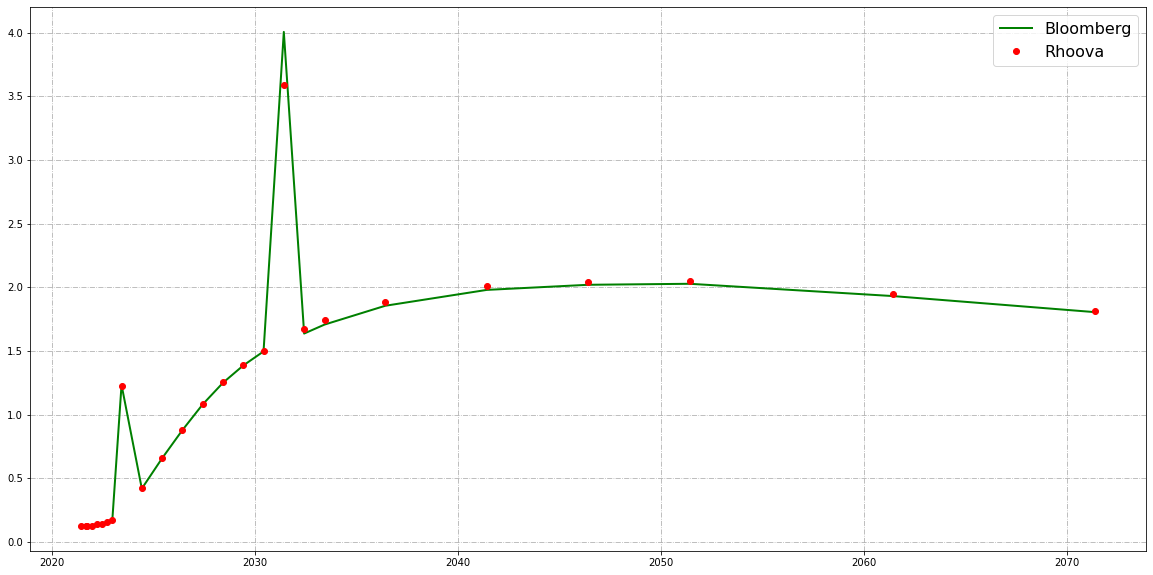

In [81]:
fig, ax = plt.subplots(figsize=(20, 10))

x=list(rhoovakryieldcurvedicts.keys())
y1 =bloombergshiftedzerorates2
y2 = list(rhoovakryieldcurvedicts.values())


ax.plot(x,y1, 'g', label='Bloomberg', linewidth=2)
ax.plot(x,y2, 'ro', label='Rhoova', linewidth=4)

leg = ax.legend(prop={'size': 16});
plt.grid(linestyle='dashdot')
plt.show()

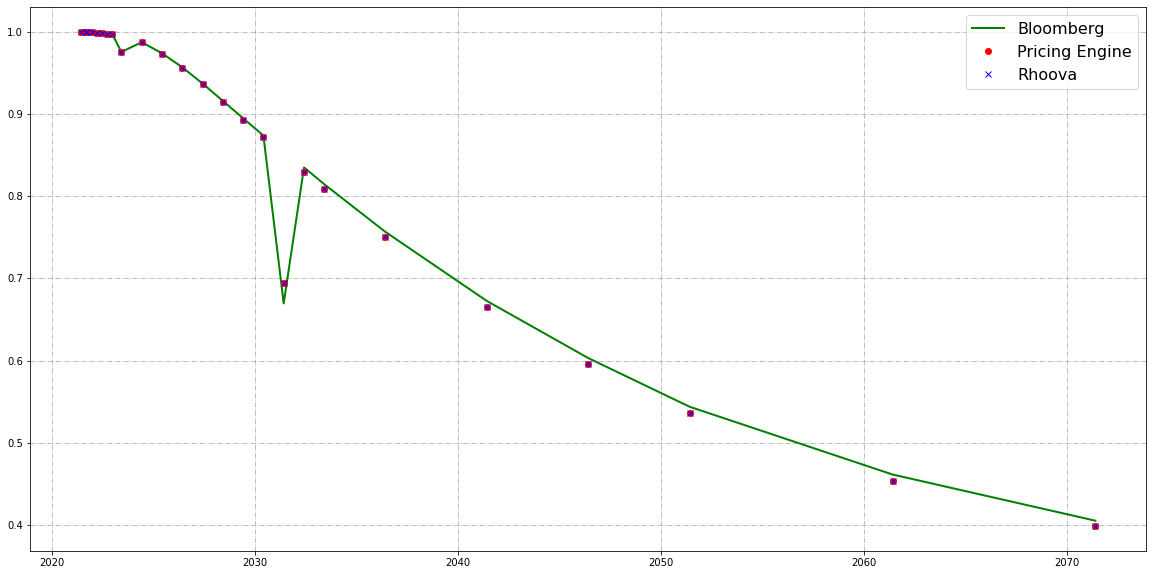

In [82]:
fig, ax = plt.subplots(figsize=(20, 10))

x=list(rhoovakryieldcurvediscounts.keys())
y1 =bloombergshifteddiscountrates2
y2 = list(rhoovakryieldcurvediscounts.values())
y3 = list(rhoovakryieldcurvediscounts.values())


ax.plot(x,y1, 'g', label='Bloomberg', linewidth=2)
ax.plot(x,y2, 'ro', label='Pricing Engine', linewidth=8)
ax.plot(x,y3, 'bx', label='Rhoova', linewidth=4)


leg = ax.legend(prop={'size': 16});
plt.grid(linestyle='dashdot')
plt.show()

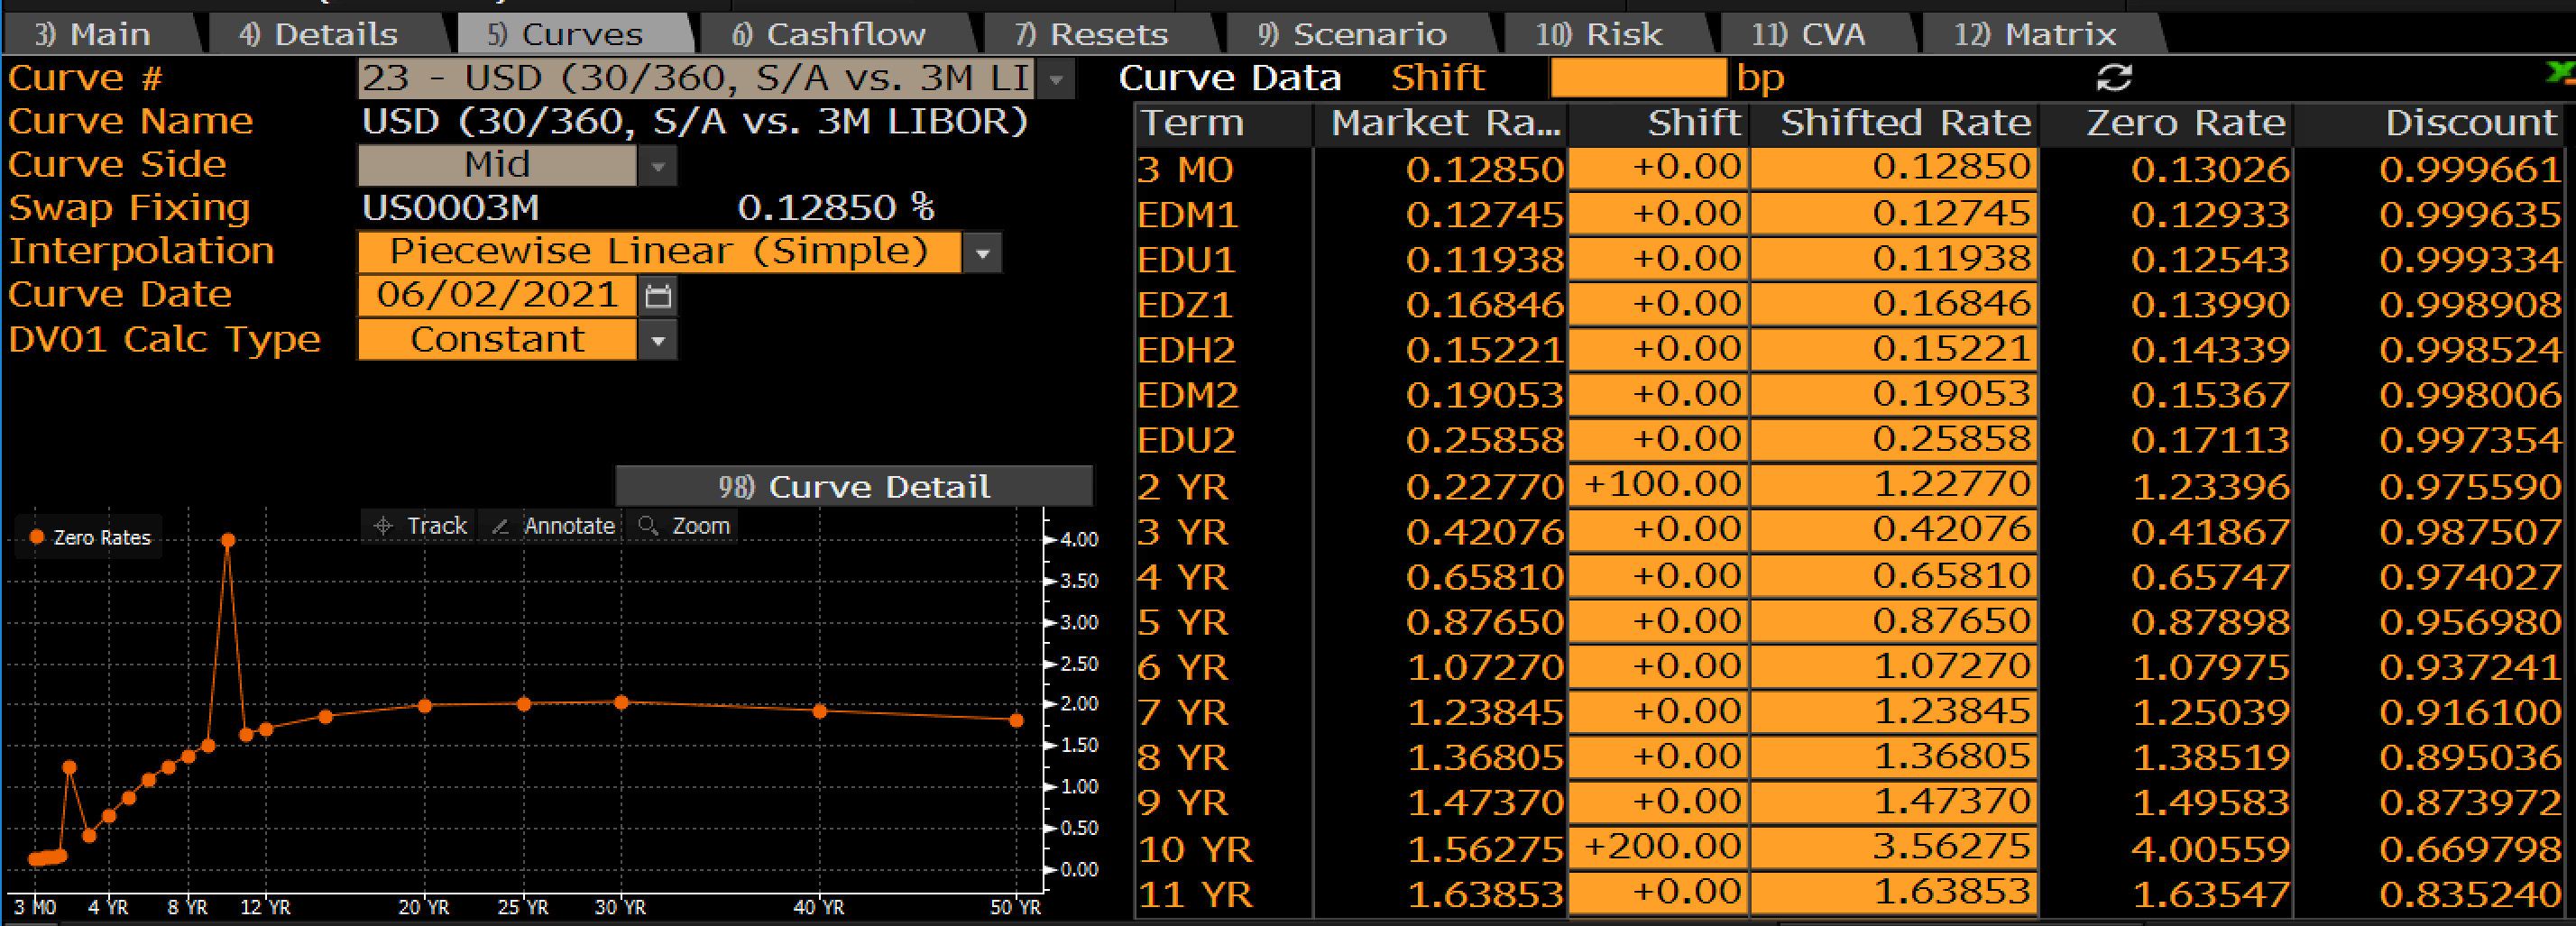

In [83]:
pTable = pt.PrettyTable(['Maturity','Rhoova ZeroRates','Bloomberg ZR','Rhoova Discount Rate','Bloomberg DR'])
i=0
for key, val in rhoovakryieldcurvedicts.items():
    pTable.add_row([key, val,bloombergshiftedzerorates2[i],rhoovakryieldcurvediscounts.get(key),bloombergshifteddiscountrates2[i]])
    i=i+1
pTable.align = 'c'
pTable.float_format = '.6'
print(pTable)

+------------+------------------+--------------+----------------------+--------------+
|  Maturity  | Rhoova ZeroRates | Bloomberg ZR | Rhoova Discount Rate | Bloomberg DR |
+------------+------------------+--------------+----------------------+--------------+
| 2021-06-04 |     0.128478     |   0.131400   |          1           |   1.000000   |
| 2021-09-07 |     0.128478     |   0.130263   |       0.999661       |   0.999661   |
| 2021-09-16 |     0.126489     |   0.129326   |       0.999635       |   0.999635   |
| 2021-12-15 |     0.124726     |   0.125427   |       0.999328       |   0.999334   |
| 2022-03-15 |     0.139854     |   0.139902   |       0.998897       |   0.998908   |
| 2022-06-16 |     0.144188     |   0.143385   |       0.998491       |   0.998524   |
| 2022-09-15 |     0.153638     |   0.153666   |       0.998005       |   0.998006   |
| 2022-12-21 |     0.172117     |   0.171127   |       0.997302       |   0.997355   |
| 2023-06-05 |     1.227698     |   1.23385

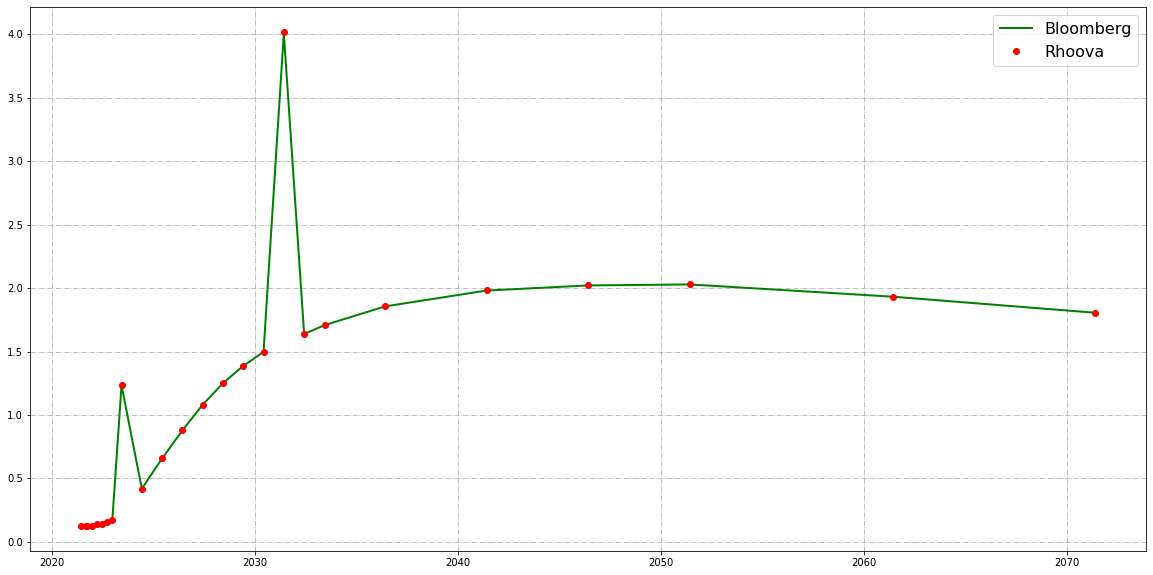

+------------+------------------+--------------+----------------------+--------------+
|  Maturity  | Rhoova ZeroRates | Bloomberg ZR | Rhoova Discount Rate | Bloomberg DR |
+------------+------------------+--------------+----------------------+--------------+
| 2021-06-04 |     0.128478     |   0.131400   |          1           |   1.000000   |
| 2021-09-07 |     0.128478     |   0.130263   |       0.999661       |   0.999661   |
| 2021-09-16 |     0.126489     |   0.129326   |       0.999635       |   0.999635   |
| 2021-12-15 |     0.124726     |   0.125427   |       0.999328       |   0.999334   |
| 2022-03-15 |     0.139854     |   0.139902   |       0.998897       |   0.998908   |
| 2022-06-16 |     0.144188     |   0.143385   |       0.998491       |   0.998524   |
| 2022-09-15 |     0.153638     |   0.153666   |       0.998005       |   0.998006   |
| 2022-12-21 |     0.172117     |   0.171127   |       0.997302       |   0.997355   |
| 2023-06-05 |     1.234035     |   1.23385

In [84]:
# Rhoova does not change maarket rate and shifts only yield curve
#Change 2Y and 10Y market rate
newyielddata=yielddata[yielddata["valuationDate"]=="2021-06-02"]
twoyearshock=newyielddata[newyielddata["tenor"]=="2Y"]["value"]+100/10000
tenyearshock=newyielddata[newyielddata["tenor"]=="10Y"]["value"]+200/10000
newyielddata.at[newyielddata.index[newyielddata['tenor'] == "2Y"].tolist()[0],'value']=twoyearshock
newyielddata.at[newyielddata.index[newyielddata['tenor'] == "10Y"].tolist()[0],'value']=tenyearshock

del yieldcurveconfig['applyShock']

yieldcurve =  {
    "valuationDate": "2021-06-02",
    "endOfMonth": True,
    "yieldCurve":yieldcurveconfig ,
    "yieldData": newyielddata.to_dict('r')
}
try:
    result = api.createTask(CalculationType.YIELD_CURVE, yieldcurve,True)
    kr2result=json.loads(result["result"])
except RhoovaError as e:
    e.printPretty()
    
zerorates=kr2result.get("zeroRates"),
discountrates=kr2result.get("discountRates")
dates=[]
forwarddates= {}
rhoovakr2yieldcurvedicts = {}
rhoovakr2yieldcurvediscounts = {}
for rhvzr in zerorates[0]:
    rhoovakr2yieldcurvedicts[datetime.strptime(rhvzr.get('date'),'%Y-%m-%d').date()] = rhvzr.get('rate')*100
    dates.append(rhvzr.get('date'))

for rhv in discountrates:
    rhoovakr2yieldcurvediscounts[datetime.strptime(rhv.get('date'), '%Y-%m-%d').date()] = rhv.get('rate')
 
fig, ax = plt.subplots(figsize=(20, 10))

x=list(rhoovakr2yieldcurvedicts.keys())
y1 =bloombergshiftedzerorates2
y2 = list(rhoovakr2yieldcurvedicts.values())


ax.plot(x,y1, 'g', label='Bloomberg', linewidth=2)
ax.plot(x,y2, 'ro', label='Rhoova', linewidth=4)

leg = ax.legend(prop={'size': 16});
plt.grid(linestyle='dashdot')
plt.show()

pTable = pt.PrettyTable(['Maturity','Rhoova ZeroRates','Bloomberg ZR','Rhoova Discount Rate','Bloomberg DR'])
i=0
for key, val in rhoovakr2yieldcurvedicts.items():
    pTable.add_row([key, val,bloombergshiftedzerorates2[i],rhoovakr2yieldcurvediscounts.get(key),bloombergshifteddiscountrates2[i]])
    i=i+1
pTable.align = 'c'
pTable.float_format = '.6'
print(pTable)

In [120]:
# Fix parameters for building yield curve
yieldcurveconfig['applyShock']={
  "method": "nonparallel",
  "shockValues" : [
    {
      "tenor" : "2Y",
      "shockValue" : 75.0
    }, 
    {
      "tenor" : "10Y",
      "shockValue" : 25.0
    }, 
    {
      "tenor" : "25Y",
      "shockValue" : 5.0
    }, 
    {
      "tenor" : "50Y",
      "shockValue" : 0.0
    }  
  ]
}

In [121]:
yieldcurve =  {
    "valuationDate": "2021-06-02",
    "endOfMonth": True,
    "yieldCurve":yieldcurveconfig ,
    "yieldData": yielddata.to_dict('r')
}


In [122]:
try:
    result = api.createTask(CalculationType.YIELD_CURVE, yieldcurve,True)
    npresult=json.loads(result["result"])
except RhoovaError as e:
    e.printPretty()


In [123]:
zerorates=npresult.get("zeroRates")
discountrates=npresult.get("discountRates")
dates=[]
forwarddates= {}
rhoovanpyieldcurvedicts = {}
rhoovanpyieldcurvediscounts = {}
for rhvzr in zerorates:
    rhoovanpyieldcurvedicts[datetime.strptime(rhvzr.get('date'),'%Y-%m-%d').date()] = rhvzr.get('rate')*100
    dates.append(rhvzr.get('date'))

for rhv in discountrates:
    rhoovanpyieldcurvediscounts[datetime.strptime(rhv.get('date'), '%Y-%m-%d').date()] = rhv.get('rate')


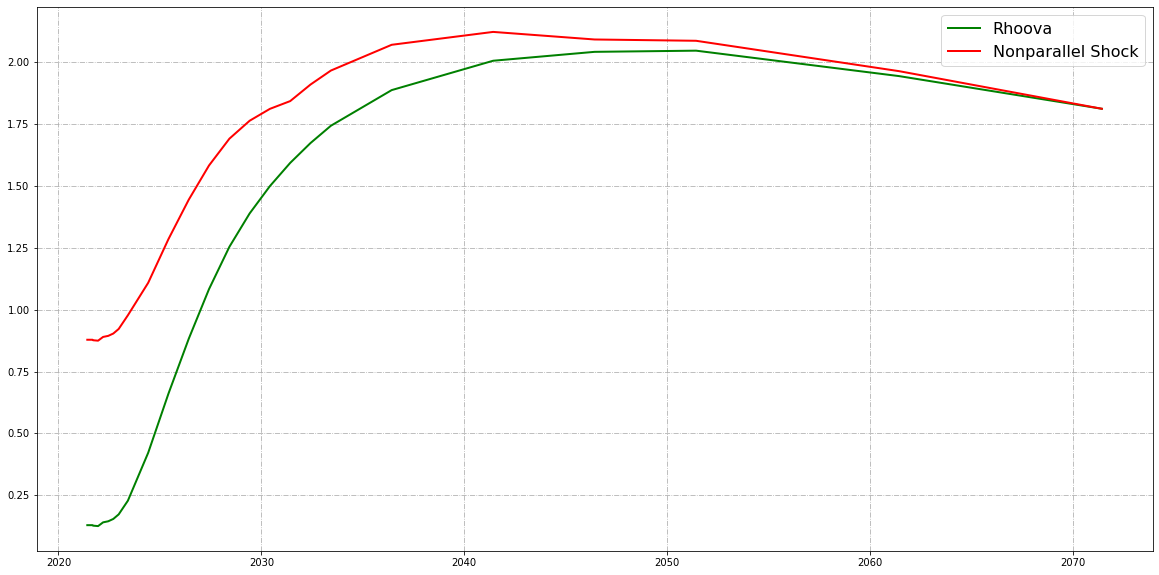

In [124]:
fig, ax = plt.subplots(figsize=(20, 10))

x=list(rhoovanpyieldcurvedicts.keys())
y1 =list(rhoovayieldcurvedicts.values())
y2 = list(rhoovanpyieldcurvedicts.values())


ax.plot(x,y1, 'g', label='Rhoova', linewidth=2)
ax.plot(x,y2, 'r', label='Nonparallel Shock', linewidth=2)

leg = ax.legend(prop={'size': 16});
plt.grid(linestyle='dashdot')
plt.show()

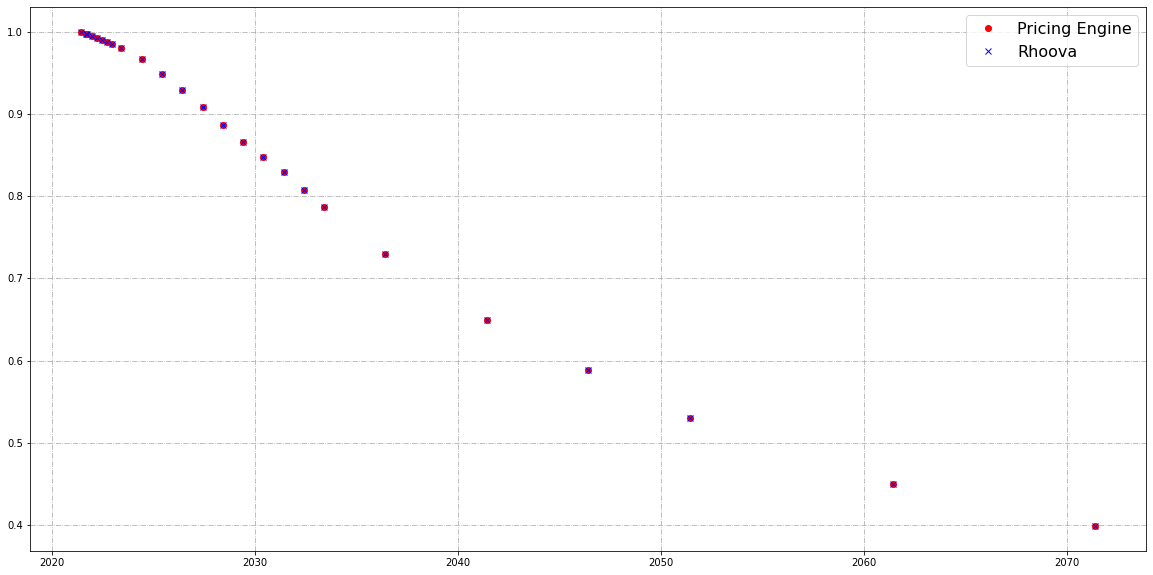

In [125]:
fig, ax = plt.subplots(figsize=(20, 10))

x=list(rhoovayieldcurvediscounts.keys())
y2 = list(rhoovanpyieldcurvediscounts.values())
y3 = list(rhoovanpyieldcurvediscounts.values())


ax.plot(x,y2, 'ro', label='Pricing Engine', linewidth=8)
ax.plot(x,y3, 'bx', label='Rhoova', linewidth=4)


leg = ax.legend(prop={'size': 16});
plt.grid(linestyle='dashdot')
plt.show()

In [126]:
pTable = pt.PrettyTable(['Maturity','Rhoova ZeroRates','Nonparallel Shock ZR','Rhoova Discount Rate','Nonparallel Shock DR'])
i=0
for key, val in rhoovayieldcurvedicts.items():
    pTable.add_row([key, val,rhoovanpyieldcurvedicts.get(key),rhoovayieldcurvediscounts.get(key),rhoovanpyieldcurvediscounts.get(key)])
    i=i+1
pTable.align = 'c'
pTable.float_format = '.6'
print(pTable)

+------------+------------------+----------------------+----------------------+----------------------+
|  Maturity  | Rhoova ZeroRates | Nonparallel Shock ZR | Rhoova Discount Rate | Nonparallel Shock DR |
+------------+------------------+----------------------+----------------------+----------------------+
| 2021-06-04 |     0.128478     |       0.878478       |          1           |          1           |
| 2021-09-07 |     0.128478     |       0.878478       |       0.999661       |       0.997684       |
| 2021-09-16 |     0.126489     |       0.876489       |       0.999635       |       0.997471       |
| 2021-12-15 |     0.124726     |       0.874726       |       0.999328       |       0.995297       |
| 2022-03-15 |     0.139854     |       0.889854       |       0.998897       |       0.993005       |
| 2022-06-16 |     0.144188     |       0.894188       |       0.998491       |       0.990680       |
| 2022-09-15 |     0.153638     |       0.903638       |       0.998005  